## 1. Imports and reading db

In [6]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [7]:
db = sqlite3.connect("../data/checking-logs.sqlite")
q = """SELECT uid, timestamp FROM checker WHERE uid LIKE 'user_%'"""
df = pd.read_sql(q, db, parse_dates=['timestamp'])
df.head()

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370


## 2. Data Preprocessing

In [8]:
week = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df['weekday'] = df['timestamp'].dt.dayofweek.map(lambda i: week[i])
df['hour']    = df['timestamp'].dt.hour
df.head

<bound method NDFrame.head of          uid                  timestamp weekday  hour
0     user_4 2020-04-17 05:19:02.744528     Fri     5
1     user_4 2020-04-17 05:22:35.249331     Fri     5
2     user_4 2020-04-17 05:22:45.549397     Fri     5
3     user_4 2020-04-17 05:34:14.691200     Fri     5
4     user_4 2020-04-17 05:34:24.422370     Fri     5
...      ...                        ...     ...   ...
3202  user_1 2020-05-21 20:19:06.872761     Thu    20
3203  user_1 2020-05-21 20:22:41.785725     Thu    20
3204  user_1 2020-05-21 20:22:41.877806     Thu    20
3205  user_1 2020-05-21 20:37:00.129678     Thu    20
3206  user_1 2020-05-21 20:37:00.290491     Thu    20

[3207 rows x 4 columns]>

In [9]:
wday_user = (df.groupby(['weekday','uid']).size().unstack(fill_value=0).reindex(week))
wday_user = wday_user[wday_user.sum().sort_values(ascending=False).index]
wday_user.head()
hour_user = (df.groupby(['hour','uid']).size().unstack(fill_value=0).reindex(range(24), fill_value=0))
hour_user = hour_user[hour_user.sum().sort_values(ascending=False).index]
hour_user.head()

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_7,user_22,user_11,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0,4,0,0,0,4,0,2,0,0,...,0,0,0,0,2,0,0,0,0,0
1,0,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Graph

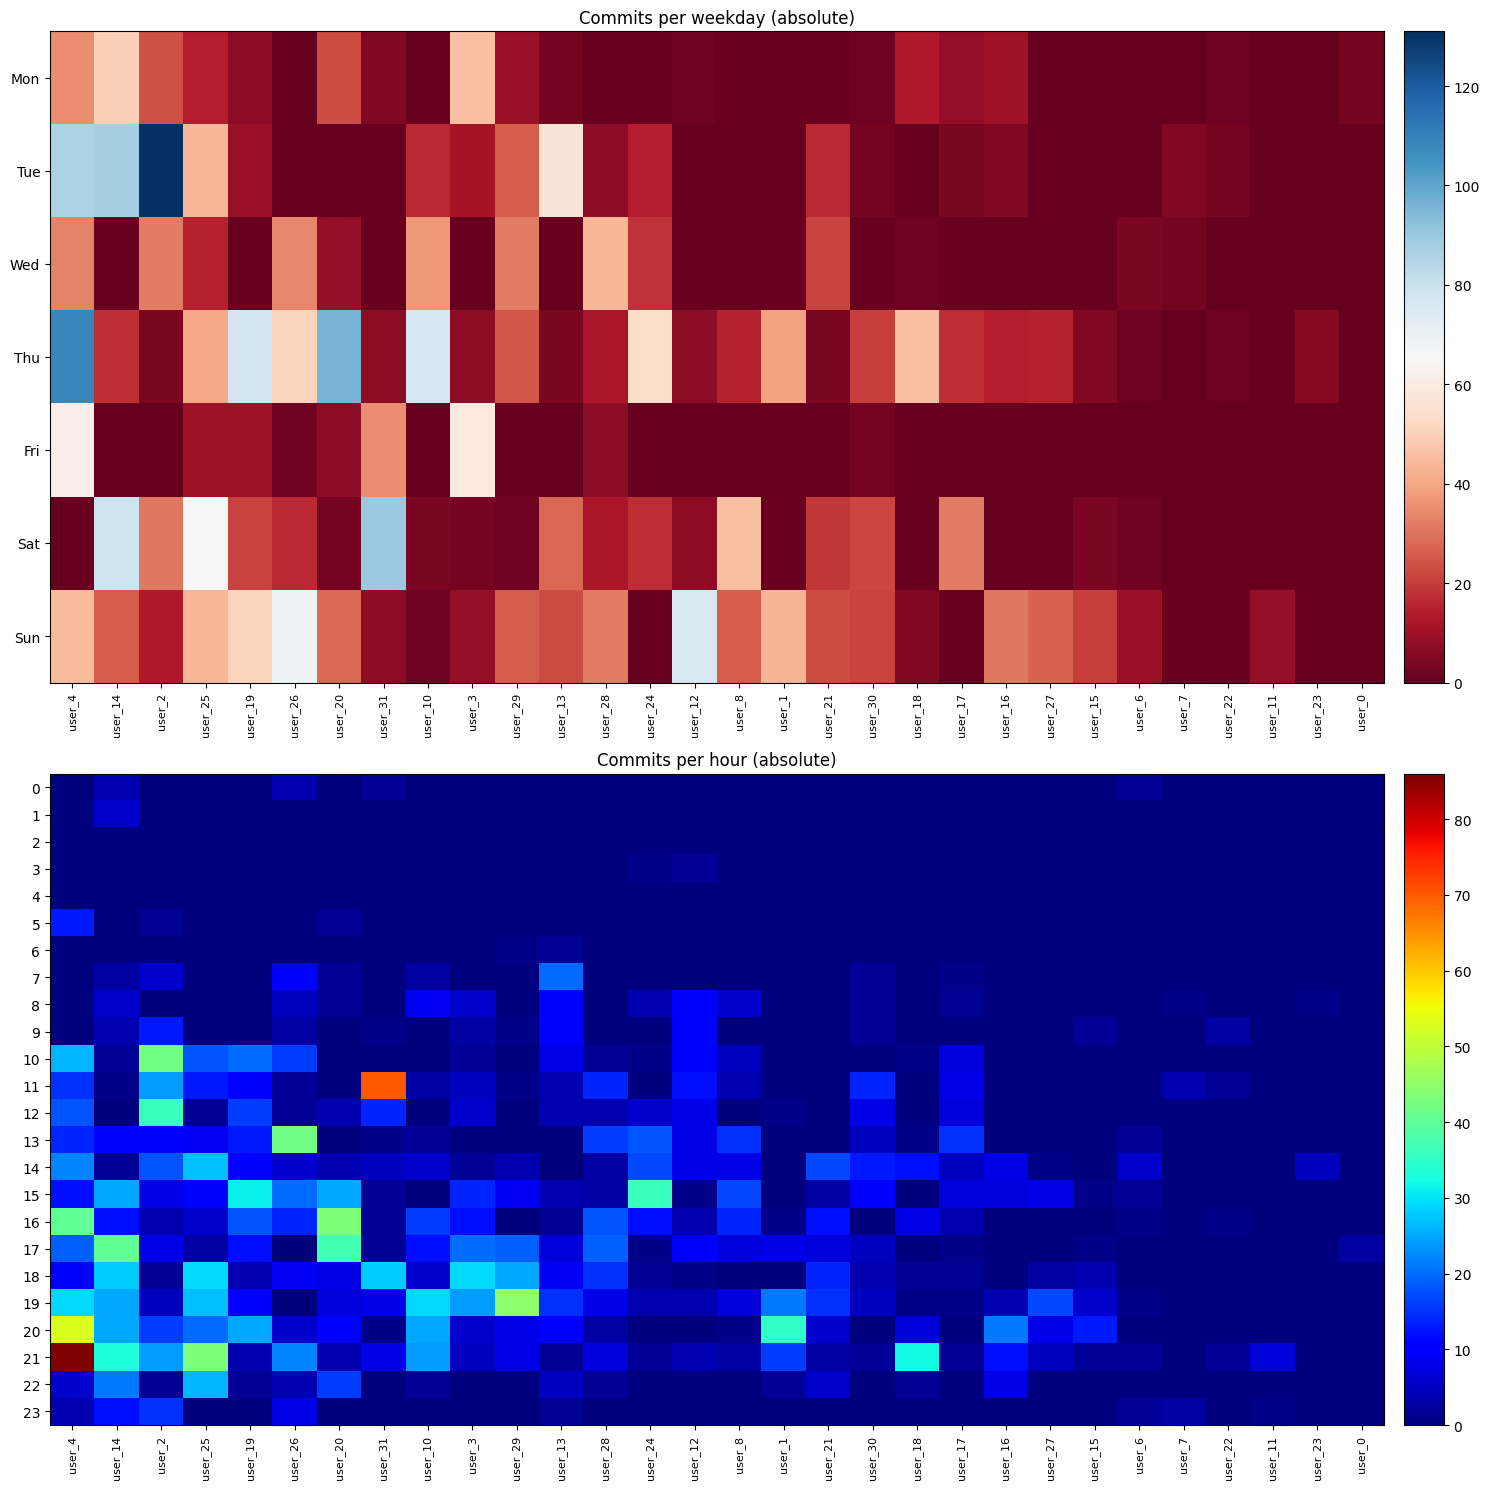

In [10]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15,15))

im1 = ax1.imshow(wday_user.values, aspect='auto', cmap='RdBu')
ax1.set_yticks(range(len(week))); ax1.set_yticklabels(week)
ax1.set_xticks(range(wday_user.shape[1])); ax1.set_xticklabels(wday_user.columns, rotation=90, fontsize=8)
ax1.set_title('Commits per weekday (absolute)')
div1 = make_axes_locatable(ax1); cax1 = div1.append_axes("right", size="3%", pad=0.2)
plt.colorbar(im1, cax=cax1)

im2 = ax2.imshow(hour_user.values, aspect='auto', cmap='jet')
ax2.set_yticks(range(24)); ax2.set_yticklabels([str(h) for h in range(24)])
ax2.set_xticks(range(hour_user.shape[1])); ax2.set_xticklabels(hour_user.columns, rotation=90, fontsize=8)
ax2.set_title('Commits per hour (absolute)')
div2 = make_axes_locatable(ax2); cax2 = div2.append_axes("right", size="3%", pad=0.2)
plt.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()

## 4. Questions
"Which user has the most commits on Tuesday?" The answer is 
- user_2.  

"Which user has the most commits on Thursday?" The answer is
- user_4.  

"On which weekday do users not like to make a lot of commits?" The answer is  
- Friday.  

"Which user made the largest number of commits at which hour?" The answer is
 - user_4, 21.

## 5. Closing

In [11]:
db.close()